# Session 35 · AI Agents and LangGraph — Practical

**Phase 10 — AI Agents & LangGraph.** Companion to the Session 35 slides.
Live time: ~12 minutes. Cost: well under a cent (a handful of `gpt-4o-mini` calls).

---

## What we are building

A tiny **self-correcting writer**. One node drafts a short explanation, a second node checks
it against a rule, and if the check fails the graph *loops back and tries again*.

That loop is the whole point. It is the same Observe → Reason → Act → Observe loop from the
first half of the session — except here the loop belongs to LangGraph rather than to a
`while` statement we wrote ourselves. Once the framework owns the loop, we get checkpointing,
inspection and resumability for free. That is the argument for LangGraph in one example.

```
        START
          |
          v
      +-------+       +--------+   PASS / out of tries
      | write | ----> | review | -----------------------> END
      +-------+       +--------+
          ^               |
          +---------------+
              REVISE
```

`write` calls an LLM. `review` is ordinary Python. **The graph does not care which** — and
seeing both side by side is half of what this notebook is for.

| Step | Concept | Minutes |
|---|---|---|
| 0 | Setup | 1 |
| 1 | **State** — the shared dictionary | 2 |
| 2 | **Nodes** — plain Python functions | 3 |
| 3 | **Edges** — static and conditional | 1 |
| 4 | **StateGraph**, `START`, `END`, `compile()` | 2 |
| 5 | **Invoke** and watch the loop run | 1 |
| 6 | **Checkpointing** — threads and history | 2 |

---

## Step 0 · Setup

`langgraph` does **not** pull in `langchain-openai`, so we need both. This is the one cell
worth running *before* the session starts.

In [ ]:
%pip install -q langgraph langchain-openai python-dotenv

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()   # expects OPENAI_API_KEY in a .env file next to this notebook
assert os.environ.get("OPENAI_API_KEY"), "OPENAI_API_KEY is not set"

from langchain_openai import ChatOpenAI

# temperature=0 so the demo behaves roughly the same each time we run it.
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# One cheap call, so a bad key fails here rather than five cells from now.
print(llm.invoke("Reply with the single word: ready").content)

c:\Users\ShahZeb\miniconda3\envs\rag_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ready


---

## Step 1 · State

**What.** State is the one dictionary that every node reads from and writes to. It *is* the
memory of the run. In LangGraph you declare its shape with a `TypedDict`.

**Why it matters.** Nodes never call each other. They only read state and return an update.
That is what keeps a graph decomposable — you can replace any node without touching the rest.

**The thing beginners get wrong:** by default, a key you return **overwrites** whatever was
there. If you want a key to *accumulate*, annotate it with a **reducer** — a function that
says how to combine the old value with the new one. `operator.add` on a list means "append".

In [2]:
from typing import Annotated, TypedDict
from operator import add


class State(TypedDict):
    topic: str                          # set once at the start
    draft: str                          # overwritten on each attempt
    feedback: str                       # overwritten by each review
    verdict: str                        # "PASS" or "REVISE"
    attempts: int                       # overwritten with a new count

    # Annotated[..., add] is the reducer. Returning ["x"] APPENDS "x"
    # instead of replacing the whole list. This is how we keep a trail.
    log: Annotated[list[str], add]

In [3]:
# What a reducer actually is, in isolation, before any graph exists.
#
#   no reducer   ->  {"attempts": 1} then {"attempts": 2}  gives  2
#   `add` reducer->  {"log": ["a"]}  then {"log": ["b"]}   gives  ["a", "b"]
#
print(add(["a"], ["b"]))     # -> ['a', 'b']    ...that is the whole idea

['a', 'b']


---

## Step 2 · Nodes

**What.** A node is a plain Python function. It takes the current state and returns a
**partial** update — only the keys it wants to change. LangGraph merges that update into
state for you.

The docs put it in six words: ***nodes do the work, edges tell what to do next.***

### Node 1 — `write` (contains an LLM call)

In [4]:
WORD_LIMIT = 25


def write(state: State) -> dict:
    '''Draft the explanation. On a retry, show the LLM its previous attempt
    and the reviewer's complaint so it can fix that specific thing.'''
    attempt = state["attempts"] + 1

    if state["feedback"]:
        prompt = (
            f"Rewrite this explanation of '{state['topic']}' for a 12-year-old.\n\n"
            f"{state['draft']}\n\n"
            f"{state['feedback']}\n"
            f"Return ONLY the rewritten explanation, {WORD_LIMIT} words or fewer."
        )
    else:
        prompt = f"Explain '{state['topic']}' to a 12-year-old in two short sentences."

    draft = llm.invoke(prompt).content.strip()

    # Return ONLY what changed. 'log' appends (it has a reducer); the rest overwrite.
    return {"draft": draft, "attempts": attempt, "log": [f"write · attempt {attempt}"]}

### Node 2 — `review` (no LLM at all, just code)

This one is deliberately plain Python. Two reasons:

1. **It proves the point.** A node is a function. Nothing about LangGraph requires a model.
   Half the nodes in a real system are validators, parsers, database reads and formatters.
2. **It is deterministic.** I originally wrote this reviewer as a second LLM call and it was
   unusable — asked to enforce a 25-word limit, `gpt-4o-mini` rejected a 24-word draft three
   times in a row. Language models cannot reliably count. If a rule can be checked in code,
   check it in code; save the model for the part that needs judgement.

In [5]:
def review(state: State) -> dict:
    '''Check the draft against one hard rule. Pure Python -- no model involved.'''
    words = len(state["draft"].split())

    if words <= WORD_LIMIT:
        return {"verdict": "PASS", "feedback": "",
                "log": [f"review · PASS ({words} words)"]}

    return {
        "verdict": "REVISE",
        "feedback": (f"An editor rejected it: too long at {words} words; "
                     f"the hard limit is {WORD_LIMIT}."),
        "log": [f"review · REVISE ({words} words, limit {WORD_LIMIT})"],
    }

In [6]:
# Proof that a node really is just a function: call them directly, no graph involved.
blank = {"topic": "gravity", "draft": "", "feedback": "",
         "verdict": "", "attempts": 0, "log": []}

drafted = write(blank)
print(drafted["draft"], "\n")
print(review({**blank, **drafted}))

Gravity is a force that pulls objects toward each other, like how the Earth pulls you down so you don't float away. It's what keeps us on the ground and makes things fall when you drop them! 

{'verdict': 'REVISE', 'feedback': 'An editor rejected it: too long at 37 words; the hard limit is 25.', 'log': ['review · REVISE (37 words, limit 25)']}


---

## Step 3 · Edges

**What.** An edge answers one question: *what runs next?*

- A **static edge** always goes to the same place — `write` always hands off to `review`.
- A **conditional edge** runs a small router function, looks at state, and picks a label.

The router below is our stopping rule. Note it has **two** ways to stop: the review passed,
*or* we have burned three attempts. That second clause is the guard against the infinite loop
we talked about in the theory half — and it is ordinary Python, not framework magic. Nothing
in LangGraph stops a badly-written graph from spinning forever; **you** have to.

In [7]:
MAX_ATTEMPTS = 3


def route(state: State) -> str:
    '''Decide what happens after 'review'. Returns a LABEL, not a node.'''
    if state["verdict"] == "PASS":
        return "done"
    if state["attempts"] >= MAX_ATTEMPTS:      # the infinite-loop guard
        return "done"
    return "revise"

---

## Step 4 · StateGraph, `START`, `END`, `compile()`

`StateGraph` is the builder that holds it all together. You give it the state schema, add
nodes, wire edges, and compile.

`START` and `END` are the two special built-in nodes. `add_edge(START, "write")` says where
execution begins; routing to `END` says the run is over.

`compile()` turns the builder into something runnable. **A `StateGraph` cannot be invoked —
only a compiled graph can.**

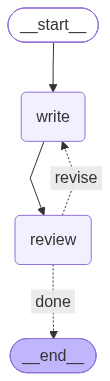

In [8]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)               # 1. the state schema

builder.add_node("write", write)          # 2. the nodes
builder.add_node("review", review)

builder.add_edge(START, "write")          # 3. where we begin
builder.add_edge("write", "review")       # 4. a static edge

builder.add_conditional_edges(            # 5. the branch
    "review",
    route,
    {"revise": "write",                   # label -> node
     "done": END},
)

graph = builder.compile()                 # 6. now it can run
graph

In [9]:
# Draw it. draw_mermaid() is plain text and needs no network -- safest in a live room.
print(graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	write(write)
	review(review)
	__end__([<p>__end__</p>]):::last
	__start__ --> write;
	review -. &nbsp;done&nbsp; .-> __end__;
	review -. &nbsp;revise&nbsp; .-> write;
	write --> review;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



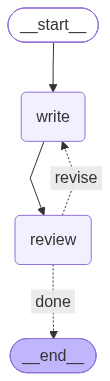

In [10]:
# Prettier version. Calls a remote renderer, so it needs internet.
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Renderer unavailable -- use the text version above.", type(e).__name__)

---

## Step 5 · Invoke

`invoke()` takes the **initial state** and runs until something routes to `END`.

Every key in the `TypedDict` needs a starting value, so we keep a blank `INITIAL` around and
override just the topic.

In [11]:
INITIAL: State = {"topic": "", "draft": "", "feedback": "",
                  "verdict": "", "attempts": 0, "log": []}

result = graph.invoke({**INITIAL, "topic": "how backpropagation trains a neural network"})

print(f"attempts: {result['attempts']}    verdict: {result['verdict']}\n")
for line in result["log"]:
    print("  ", line)
print(f"\nFINAL DRAFT ({len(result['draft'].split())} words)\n{result['draft']}")

attempts: 2    verdict: PASS

   write · attempt 1
   review · REVISE (47 words, limit 25)
   write · attempt 2
   review · PASS (24 words)

FINAL DRAFT (24 words)
Backpropagation is like a teacher correcting a student. It helps the neural network learn from mistakes, so it gets better at making smart guesses!


Read the `log`. `write · attempt 1` → `review · REVISE` → `write · attempt 2` →
`review · PASS` means **the graph looped**. Nothing in our code says "loop" — the conditional
edge simply pointed back at `write`, and the runtime followed it.

`stream()` shows the same run one node at a time, which is how you normally debug a graph:

In [12]:
for step in graph.stream({**INITIAL, "topic": "what overfitting is"}):
    node = list(step)[0]
    update = step[node]
    print(f"{node:>7} -> updated {sorted(update)}")

  write -> updated ['attempts', 'draft', 'log']
 review -> updated ['feedback', 'log', 'verdict']
  write -> updated ['attempts', 'draft', 'log']
 review -> updated ['feedback', 'log', 'verdict']


---

## Step 6 · Checkpointing

Everything so far has been stateless: once `invoke()` returned, the run was gone. If it had
crashed on attempt three, we would have had nothing.

A **checkpointer** saves a snapshot of state after every step. Snapshots are grouped into a
**thread**, identified by a `thread_id` you pass at call time. Same `thread_id`, same history.

`InMemorySaver` keeps them in RAM — fine for a demo. `SqliteSaver` and `PostgresSaver` are
drop-in replacements for real systems.

In [13]:
from langgraph.checkpoint.memory import InMemorySaver

# Exactly the same builder. The only difference is the checkpointer.
memory_graph = builder.compile(checkpointer=InMemorySaver())

config = {"configurable": {"thread_id": "session-35-demo"}}

memory_graph.invoke({**INITIAL, "topic": "what a GPU does"}, config)
print("run complete")

run complete


In [14]:
# The latest snapshot for this thread.
snap = memory_graph.get_state(config)

print("next node(s):", snap.next)          # () means the run finished
print("attempts   :", snap.values["attempts"])
print("verdict    :", snap.values["verdict"])

next node(s): ()
attempts   : 3
verdict    : REVISE


In [15]:
# The full history -- one snapshot per step, newest first.
history = list(memory_graph.get_state_history(config))
print(f"{len(history)} checkpoints\n")

for s in reversed(history):                # reversed = chronological
    nxt = s.next or ("END",)
    print(f"step {s.metadata['step']:>2} | next={str(nxt):<12} "
          f"| attempts={s.values.get('attempts')} | verdict={s.values.get('verdict')!r}")

8 checkpoints

step -1 | next=('__start__',) | attempts=None | verdict=None
step  0 | next=('write',)   | attempts=0 | verdict=''
step  1 | next=('review',)  | attempts=1 | verdict=''
step  2 | next=('write',)   | attempts=1 | verdict='REVISE'
step  3 | next=('review',)  | attempts=2 | verdict='REVISE'
step  4 | next=('write',)   | attempts=2 | verdict='REVISE'
step  5 | next=('review',)  | attempts=3 | verdict='REVISE'
step  6 | next=('END',)     | attempts=3 | verdict='REVISE'


That table is the run's flight recorder. Every loop iteration is a separate checkpoint, with
state exactly as it was at that moment.

Notice this run probably ended with `verdict='REVISE'` and `attempts=3` — the writer never got
under the limit, so **`MAX_ATTEMPTS` stopped it**, not success. Compare that with Step 5, which
passed on attempt two. Same graph, two different exits: one because the work was done, one
because we ran out of patience. Both are things a real agent has to handle.

This is what makes the rest possible: **resume** after a crash (restart from the last good
checkpoint), **time travel** (replay from any checkpoint to debug), **memory** (send a
follow-up on the same thread and it remembers), and **human-in-the-loop** (pause, let a
person edit state, continue). We are not building those today — but they all sit on top of
exactly this table.

A different `thread_id` is a different, empty world:

In [16]:
fresh = memory_graph.get_state({"configurable": {"thread_id": "somebody-else"}})
print("state on an unused thread:", fresh.values)      # {}

state on an unused thread: {}


In [17]:
# For production, swap one line. (Not run here -- needs `pip install langgraph-checkpoint-sqlite`.)
#
#   from langgraph.checkpoint.sqlite import SqliteSaver
#
#   with SqliteSaver.from_conn_string("checkpoints.db") as saver:
#       durable_graph = builder.compile(checkpointer=saver)
#
# Every line above this cell stays identical.
print("SqliteSaver and PostgresSaver are drop-in replacements for InMemorySaver.")

SqliteSaver and PostgresSaver are drop-in replacements for InMemorySaver.


---

## Recap

| Concept | What we wrote |
|---|---|
| **State** | a `TypedDict`; `Annotated[list, add]` to accumulate instead of overwrite |
| **Node** | a function `state -> partial update` — LLM optional |
| **Static edge** | `add_edge("write", "review")` |
| **Conditional edge** | `add_conditional_edges("review", route, {...})` — this made the loop |
| **StateGraph** | `StateGraph(State)` → `add_node` → `add_edge` → `.compile()` |
| **`START` / `END`** | where execution enters and leaves |
| **Checkpointing** | `compile(checkpointer=InMemorySaver())` plus a `thread_id` |

Three things worth carrying out of the room:

1. A node is **just a function**. There is no hidden agent magic — one of ours calls a model,
   the other counts words.
2. The loop lives in the **graph**, not in your code. That is the trade: you hand over the
   loop, and in exchange the runtime can checkpoint it, stream it, pause it and resume it.
3. **You** own the stopping condition. `MAX_ATTEMPTS` is three lines of ordinary Python and it
   is the only thing standing between this graph and an infinite loop.

### Optional exercises

- Set `WORD_LIMIT = 15` and re-run. Does it ever pass? What does `MAX_ATTEMPTS` do?
- Add a third node, `polish`, between a passing review and `END`.
- Add a `style` key to the state and have `write` read it.
- Run two topics on two different `thread_id`s and compare their histories.

**Next session:** tools and tool-calling nodes, `ToolNode`, and multi-agent graphs.